# Friction Factors 
Creates Friction Factors based on calibrated gamma parameters in .dat format, ready to be consumed by CUBE application. 

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
input_file = Path("C:/Users/USJC173858/temp/baseline/nonres/truckFF.dat")
output_file = Path("../models/trip_distribution/truckFF_distance_based.dat")

In [3]:
df = pd.read_csv(
    input_file, 
    sep="\t", 
    header=None,
    names=["Time", "VerySmall", "Small", "Medium", "Large"]
)

In [4]:
df.head()

,Time,VerySmall,Small,Medium,Large
0,1,140831,9231,9048,9704
1,2,123840,8521,8187,9418
2,3,107354,7866,7408,9139
3,4,93063,7261,6703,8869
4,5,80675,6703,6065,8607


## TM 1.6 - Gamma Distributions

Verified Column Sums:
VerySmall    1.0
Small        1.0
Medium       1.0
Large        1.0
dtype: float64


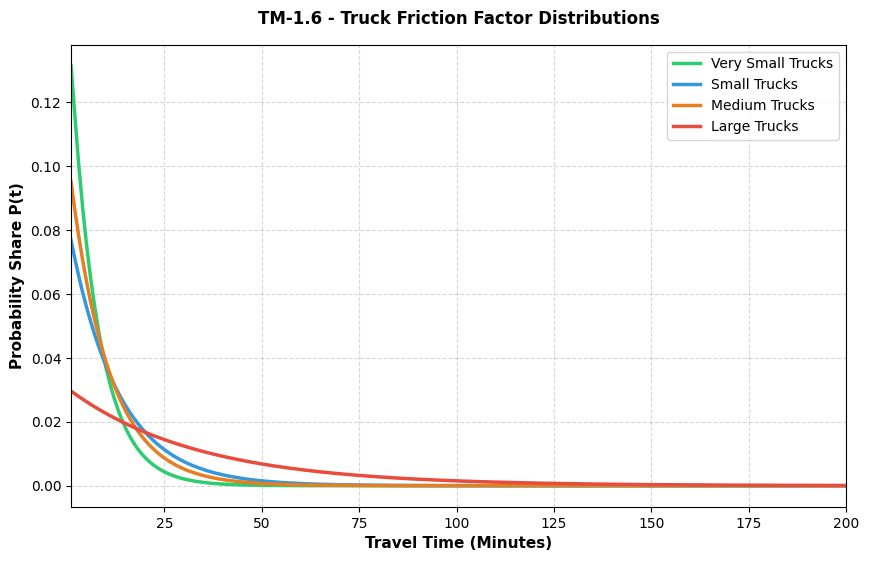

In [5]:
df_prob = df.copy()
for col in ["VerySmall", "Small", "Medium", "Large"]:
    df_prob[col] = df[col] / df[col].sum()

# Quick verification check to print out the new column sums (should all be 1.0)
print("Verified Column Sums:")
print(df_prob[["VerySmall", "Small", "Medium", "Large"]].sum())

# 3. Initialize the plot
plt.figure(figsize=(10, 6))

# 4. Plot the probability mass curves
plt.plot(df_prob["Time"], df_prob["VerySmall"], label="Very Small Trucks", color="#2ecc71", linewidth=2.5)
plt.plot(df_prob["Time"], df_prob["Small"], label="Small Trucks", color="#3498db", linewidth=2.5)
plt.plot(df_prob["Time"], df_prob["Medium"], label="Medium Trucks", color="#e67e22", linewidth=2.5)
plt.plot(df_prob["Time"], df_prob["Large"], label="Large Trucks", color="#e74c3c", linewidth=2.5)

# 5. Fine-tune visual parameters for probability layouts
plt.xlim(1, df_prob["Time"].max())
plt.xlabel("Travel Time (Minutes)", fontsize=11, fontweight="bold")
plt.ylabel("Probability Share P(t)", fontsize=11, fontweight="bold")
plt.title("TM-1.6 - Truck Friction Factor Distributions", fontsize=12, fontweight="bold", pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right")

# Display the clean distribution plot
plt.show()

In [6]:
df

,Time,VerySmall,Small,Medium,Large
0,1,140831,9231,9048,9704
1,2,123840,8521,8187,9418
2,3,107354,7866,7408,9139
3,4,93063,7261,6703,8869
4,5,80675,6703,6065,8607
...,...,...,...,...,...
195,196,0,0,0,28
196,197,0,0,0,27
197,198,0,0,0,26
198,199,0,0,0,26


## TM 1.7 Gamma Distributions

In [7]:
# First Value is b, second value is c 
# These values are estimated using src.models.trip_distribution.run
params = {
    "Small": (-0.01, -0.0872174525397631),  
    "Medium": (-0.125249395605674, -0.0574585849565377),  
    "Large": (-0.01, -0.0140827140230685)          
}

distance_ff = df

# We keep an "a" scaling constant of 1,000 to keep numbers as safe integers
# This is an arbitrary number to avoid small numbers if gamma computation that 
# could result in a underflow problem. 
a_scale = 1_000
t = distance_ff["Time"].values

for col, (b, c) in params.items():
    # Vectorized calculation over the entire 't' array at once
    raw_decimals = (t ** b) * np.exp(c * t)
    
    # Scale up, round cleanly, and force to standard integer types
    distance_ff[col] = np.round(raw_decimals * a_scale).astype(int)

In [8]:
distance_ff

,Time,VerySmall,Small,Medium,Large
0,1,140831,916,944,986
1,2,123840,834,817,966
2,3,107354,761,733,948
3,4,93063,696,668,932
4,5,80675,636,613,917
...,...,...,...,...,...
195,196,0,0,0,60
196,197,0,0,0,59
197,198,0,0,0,58
198,199,0,0,0,58


Verified Column Sums:
VerySmall    1.0
Small        1.0
Medium       1.0
Large        1.0
dtype: float64


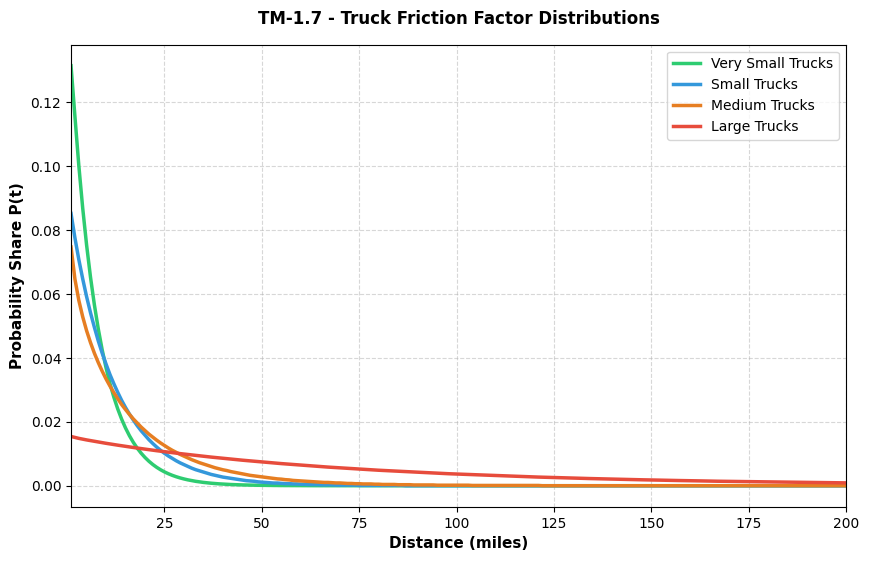

In [9]:
df_prob = distance_ff.copy()
for col in ["VerySmall", "Small", "Medium", "Large"]:
    df_prob[col] = df[col] / df[col].sum()

# Quick verification check to print out the new column sums (should all be 1.0)
print("Verified Column Sums:")
print(df_prob[["VerySmall", "Small", "Medium", "Large"]].sum())

# 3. Initialize the plot
plt.figure(figsize=(10, 6))

# 4. Plot the probability mass curves
plt.plot(df_prob["Time"], df_prob["VerySmall"], label="Very Small Trucks", color="#2ecc71", linewidth=2.5)
plt.plot(df_prob["Time"], df_prob["Small"], label="Small Trucks", color="#3498db", linewidth=2.5)
plt.plot(df_prob["Time"], df_prob["Medium"], label="Medium Trucks", color="#e67e22", linewidth=2.5)
plt.plot(df_prob["Time"], df_prob["Large"], label="Large Trucks", color="#e74c3c", linewidth=2.5)

# 5. Fine-tune visual parameters for probability layouts
plt.xlim(1, df_prob["Time"].max())
plt.xlabel("Distance (miles)", fontsize=11, fontweight="bold")
plt.ylabel("Probability Share P(t)", fontsize=11, fontweight="bold")
plt.title("TM-1.7 - Truck Friction Factor Distributions", fontsize=12, fontweight="bold", pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right")

# Display the clean distribution plot
plt.show()

In [10]:
distance_ff = distance_ff.astype(int) # No floating decimals get written out
distance_ff.to_csv(
    output_file, 
    sep="\t", 
    header=False, 
    index=False
)

In [11]:
distance_ff

,Time,VerySmall,Small,Medium,Large
0,1,140831,916,944,986
1,2,123840,834,817,966
2,3,107354,761,733,948
3,4,93063,696,668,932
4,5,80675,636,613,917
...,...,...,...,...,...
195,196,0,0,0,60
196,197,0,0,0,59
197,198,0,0,0,58
198,199,0,0,0,58
